In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [5]:
df=pd.read_csv(r"C:\Users\ayush kumar gupta\Downloads\archive (2) (1)\retail_sales_dataset.csv")
df.shape

(1000, 9)

In [3]:
df.head(10)

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100
5,6,2023-04-25,CUST006,Female,45,Beauty,1,30,30
6,7,2023-03-13,CUST007,Male,46,Clothing,2,25,50
7,8,2023-02-22,CUST008,Male,30,Electronics,4,25,100
8,9,2023-12-13,CUST009,Male,63,Electronics,2,300,600
9,10,2023-10-07,CUST010,Female,52,Clothing,4,50,200


In [6]:
df.columns.tolist()

['Transaction ID',
 'Date',
 'Customer ID',
 'Gender',
 'Age',
 'Product Category',
 'Quantity',
 'Price per Unit',
 'Total Amount']

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Transaction ID    1000 non-null   int64 
 1   Date              1000 non-null   object
 2   Customer ID       1000 non-null   object
 3   Gender            1000 non-null   object
 4   Age               1000 non-null   int64 
 5   Product Category  1000 non-null   object
 6   Quantity          1000 non-null   int64 
 7   Price per Unit    1000 non-null   int64 
 8   Total Amount      1000 non-null   int64 
dtypes: int64(5), object(4)
memory usage: 70.4+ KB


In [8]:
df.describe()

,Transaction ID,Age,Quantity,Price per Unit,Total Amount
count,1000.000000,1000.00000,1000.000000,1000.000000,1000.000000
mean,500.500000,41.39200,2.514000,179.890000,456.000000
std,288.819436,13.68143,1.132734,189.681356,559.997632
min,1.000000,18.00000,1.000000,25.000000,25.000000
25%,250.750000,29.00000,1.000000,30.000000,60.000000
50%,500.500000,42.00000,3.000000,50.000000,135.000000
75%,750.250000,53.00000,4.000000,300.000000,900.000000
max,1000.000000,64.00000,4.000000,500.000000,2000.000000


In [9]:
df.isnull().sum()

Transaction ID      0
Date                0
Customer ID         0
Gender              0
Age                 0
Product Category    0
Quantity            0
Price per Unit      0
Total Amount        0
dtype: int64

In [10]:
df.duplicated().sum()

np.int64(0)

In [13]:
print(df['Product Category'].unique())
print(df['Gender'].unique())

['Beauty' 'Clothing' 'Electronics']
['Male' 'Female']


In [14]:
#emoving duplicates for validation
df.drop_duplicates(inplace=True)
df.reset_index(drop=True, inplace=True)

In [15]:
#fix date datatype
df['Date'] = pd.to_datetime(df['Date'])
print("date column type now:", df['Date'].dtype)

date column type now: datetime64[ns]


In [16]:
# extracting month and year from date
# this will help in time series analysis later
df['Month'] = df['Date'].dt.month
df['Year'] = df['Date'].dt.year
df['Month_Name'] = df['Date'].dt.strftime('%B')

df.head()

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount,Month,Year,Month_Name
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150,11,2023,November
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000,2,2023,February
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30,1,2023,January
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500,5,2023,May
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100,5,2023,May


In [17]:
# basic stats
print("average age of customers:", round(df['Age'].mean(), 2))
print("average total amount spent:", round(df['Total Amount'].mean(), 2))
print("total revenue:", df['Total Amount'].sum())
print("most common product category:", df['Product Category'].mode()[0])
print("most common gender:", df['Gender'].mode()[0])

average age of customers: 41.39
average total amount spent: 456.0
total revenue: 456000
most common product category: Clothing
most common gender: Female


In [20]:
# median and mode
print("median total amount:", df['Total Amount'].median())
print("mode of quantity:", df['Quantity'].mode()[0])
print("std of total amount:", round(df['Total Amount'].std(), 2))


median total amount: 135.0
mode of quantity: 4
std of total amount: 560.0


In [21]:
# total sales per product category
print("total sales by category:")
print(df.groupby('Product Category')['Total Amount'].sum())

total sales by category:
Product Category
Beauty         143515
Clothing       155580
Electronics    156905
Name: Total Amount, dtype: int64


In [22]:
# average spending by gender
print("average spending by gender:")
print(df.groupby('Gender')['Total Amount'].mean())

average spending by gender:
Gender
Female    456.549020
Male      455.428571
Name: Total Amount, dtype: float64


In [23]:
# grouping sales by month
monthly_sales = df.groupby('Month')['Total Amount'].sum()
print(monthly_sales)

Month
1     36980
2     44060
3     28990
4     33870
5     53150
6     36715
7     35465
8     36960
9     23620
10    46580
11    34920
12    44690
Name: Total Amount, dtype: int64


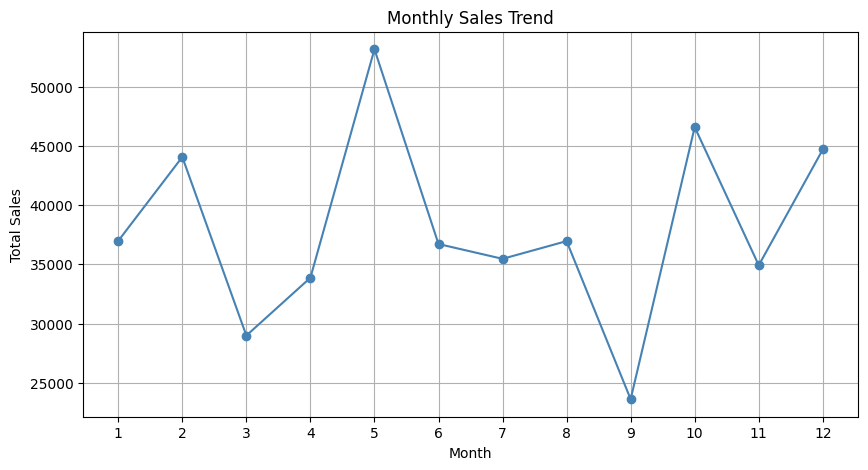

In [24]:
# plotting monthly sales trend
plt.figure(figsize=(10, 5))
plt.plot(monthly_sales.index, monthly_sales.values, marker='o', color='steelblue')
plt.title('Monthly Sales Trend')
plt.xlabel('Month')
plt.ylabel('Total Sales')
plt.xticks(range(1, 13))
plt.grid(True)
plt.show()

In [25]:
# i noticed some months have higher sales
# lets check which month has highest sales
print("month with highest sales:", monthly_sales.idxmax())
print("month with lowest sales:", monthly_sales.idxmin())

month with highest sales: 5
month with lowest sales: 9


In [27]:
# yearly sales if data has multiple years
print("sales by year:")
print(df.groupby('Year')['Total Amount'].sum())

sales by year:
Year
2023    454470
2024      1530
Name: Total Amount, dtype: int64


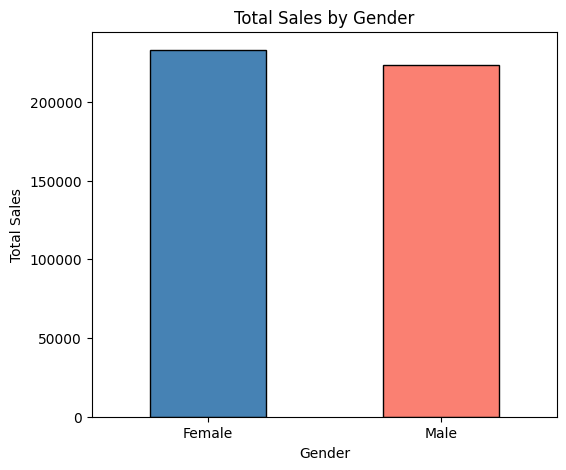

In [28]:
# sales by gender
gender_sales = df.groupby('Gender')['Total Amount'].sum()

plt.figure(figsize=(6, 5))
gender_sales.plot(kind='bar', color=['steelblue', 'salmon'], edgecolor='black')
plt.title('Total Sales by Gender')
plt.xlabel('Gender')
plt.ylabel('Total Sales')
plt.xticks(rotation=0)
plt.show()

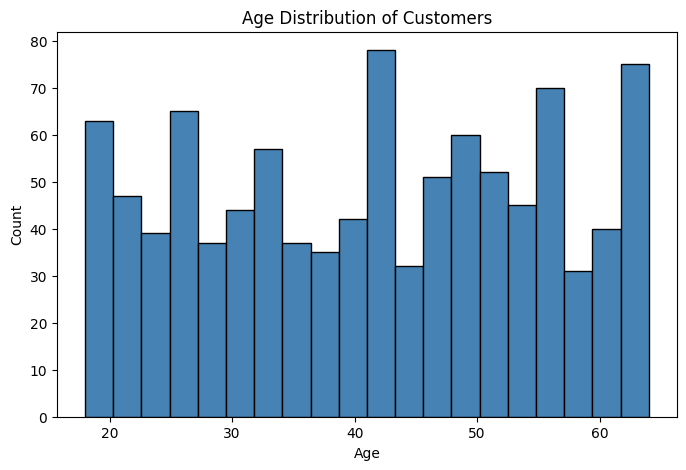

In [29]:
# age distribution of customers
plt.figure(figsize=(8, 5))
plt.hist(df['Age'], bins=20, color='steelblue', edgecolor='black')
plt.title('Age Distribution of Customers')
plt.xlabel('Age')
plt.ylabel('Count')
plt.show()

In [30]:
# creating age groups to understand which age group spends more
# i came up with these groups myself based on the data range
df['Age Group'] = pd.cut(df['Age'],
                          bins=[0, 25, 35, 45, 60, 100],
                          labels=['18-25', '26-35', '36-45', '46-60', '60+'])

age_group_sales = df.groupby('Age Group')['Total Amount'].sum()
print("sales by age group:")
print(age_group_sales)

sales by age group:
Age Group
18-25     84550
26-35     98480
36-45     91870
46-60    147875
60+       33225
Name: Total Amount, dtype: int64


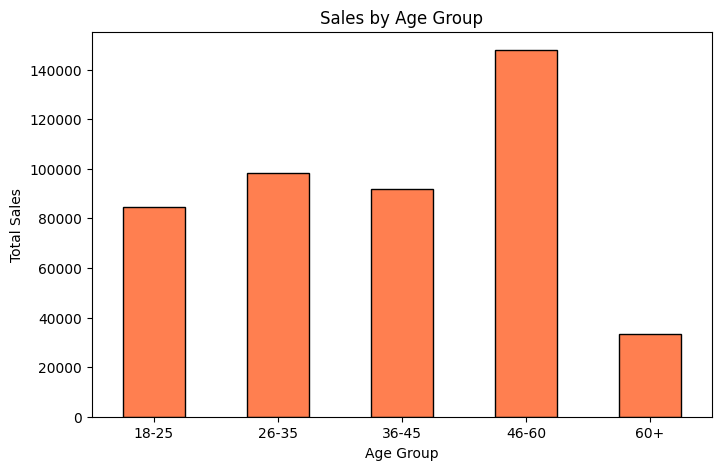

In [31]:
plt.figure(figsize=(8, 5))
age_group_sales.plot(kind='bar', color='coral', edgecolor='black')
plt.title('Sales by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Total Sales')
plt.xticks(rotation=0)
plt.show()

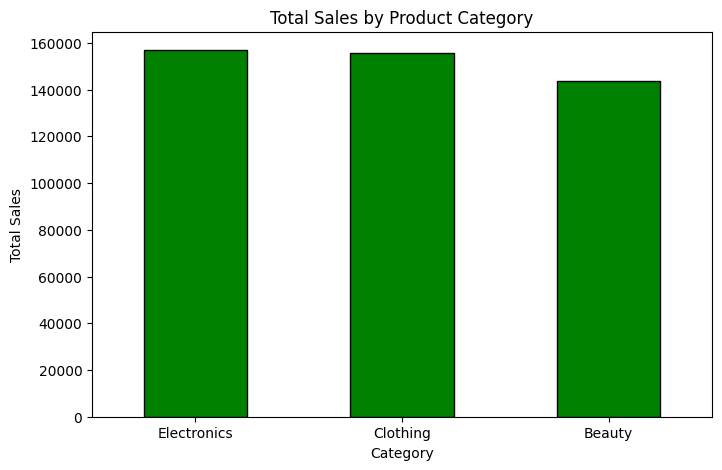

In [32]:
# total sales by product category
category_sales = df.groupby('Product Category')['Total Amount'].sum().sort_values(ascending=False)

plt.figure(figsize=(8, 5))
category_sales.plot(kind='bar', color='green', edgecolor='black')
plt.title('Total Sales by Product Category')
plt.xlabel('Category')
plt.ylabel('Total Sales')
plt.xticks(rotation=0)
plt.show()

In [33]:
# quantity sold per category
category_qty = df.groupby('Product Category')['Quantity'].sum().sort_values(ascending=False)
print("quantity sold per category:")
print(category_qty)

quantity sold per category:
Product Category
Clothing       894
Electronics    849
Beauty         771
Name: Quantity, dtype: int64


In [34]:
# average price per unit by category
avg_price = df.groupby('Product Category')['Price per Unit'].mean()
print("average price per unit by category:")
print(avg_price)

average price per unit by category:
Product Category
Beauty         184.055375
Clothing       174.287749
Electronics    181.900585
Name: Price per Unit, dtype: float64


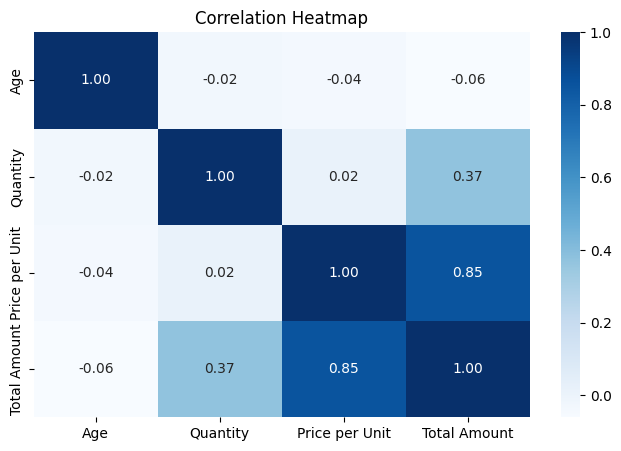

In [35]:
# heatmap of correlation
plt.figure(figsize=(8, 5))
numeric_cols = df[['Age', 'Quantity', 'Price per Unit', 'Total Amount']]
sns.heatmap(numeric_cols.corr(), annot=True, cmap='Blues', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()

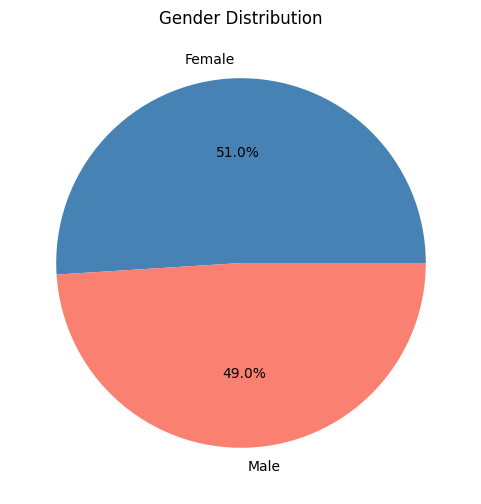

In [36]:
# pie chart for gender distribution
gender_count = df['Gender'].value_counts()

plt.figure(figsize=(6, 6))
plt.pie(gender_count.values, labels=gender_count.index,
        autopct='%1.1f%%', colors=['steelblue', 'salmon'])
plt.title('Gender Distribution')
plt.show()

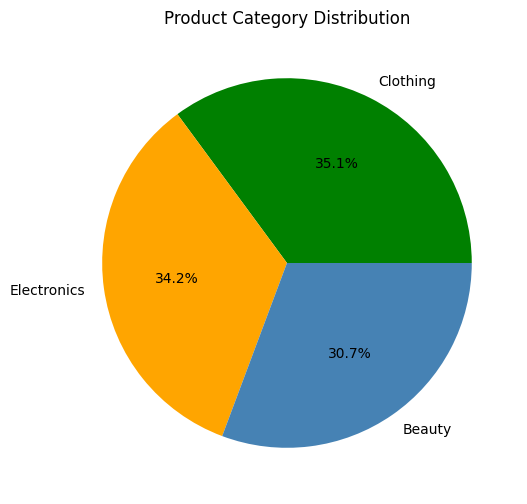

In [37]:
# pie chart for product category distribution
category_count = df['Product Category'].value_counts()

plt.figure(figsize=(6, 6))
plt.pie(category_count.values, labels=category_count.index,
        autopct='%1.1f%%', colors=['green', 'orange', 'steelblue'])
plt.title('Product Category Distribution')
plt.show()

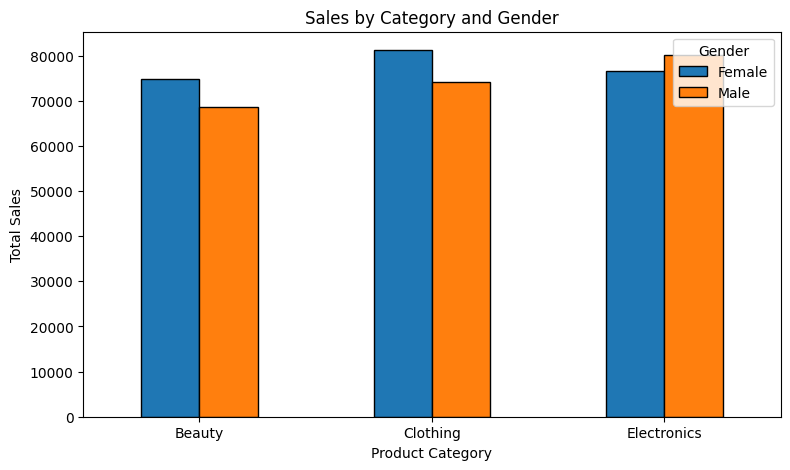

In [38]:
# sales by category and gender combined
category_gender = df.groupby(['Product Category', 'Gender'])['Total Amount'].sum().unstack()

category_gender.plot(kind='bar', figsize=(9, 5), edgecolor='black')
plt.title('Sales by Category and Gender')
plt.xlabel('Product Category')
plt.ylabel('Total Sales')
plt.xticks(rotation=0)
plt.legend(title='Gender')
plt.show()

In [39]:
#summary
print("total transactions:", len(df))
print("total revenue:", df['Total Amount'].sum())
print("average order value:", round(df['Total Amount'].mean(), 2))
print("top selling category:", category_sales.idxmax())
print("least selling category:", category_sales.idxmin())
print("best sales month:", monthly_sales.idxmax())

=== Summary ===
total transactions: 1000
total revenue: 456000
average order value: 456.0
top selling category: Electronics
least selling category: Beauty
best sales month: 5


In [40]:
# my observations from this analysis

# 1. electronics seems to bring in the most revenue
# 2. both male and female customers spend almost equally
# 3. customers between 26 to 45 age group spend the most
# 4. sales are not evenly distributed across all months
# 5. quantity sold is highest for clothing but revenue is highest for electronics

print("done")

done


In [41]:
df.to_csv("retail_sales_cleaned.csv", index=False)